In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, norm
import seaborn as sns
import matplotlib as mpl

# Model definitions
MODELS = {
    "ST_PST19": dict(file="datafiles/ST_PST19", color="tab:pink",   label="Riley19: ST+PST"),
    "ST_PDT":   dict(file="datafiles/ST_PDT",   color="tab:blue",   label="Vinciguerra23: ST+PDT"),
    "ST_PST":   dict(file="datafiles/ST_PST",   color="tab:orange", label="Vinciguerra23: ST+PST"),
    "PDT_U":    dict(file="datafiles/PDT_U",    color="tab:green",  label="Vinciguerra23: PDT--U"),
    "ST_U":     dict(file="datafiles/ST_U",     color="tab:cyan",   label="Vinciguerra23: ST--U"),
    "2spot":    dict(file="datafiles/2spot",    color="tab:red",    label="Miller19: 2spot"),
    "3spot":    dict(file="datafiles/3spot",    color="tab:purple", label="Miller19: 3spot"),
    "PDT_U26": dict(file="datafiles/equal_weight_samples_PDTU.txt",  color="tab:olive",  label="Kini26: PDT--U"),
}

# ------------------------------------------------------------
# Load data and compute summary statistics
# ------------------------------------------------------------

samples_MR = {}

M_med, M_lo, M_hi, S_Mi = {}, {}, {}, {}
R_med, R_lo, R_hi, S_Ri = {}, {}, {}, {}
KDEs = {}
for key, meta in MODELS.items():

    data = np.loadtxt(meta["file"])
    M, R = data.T[0], data.T[1]

    samples_MR[key] = np.vstack([M, R])

    # Mass statistics
    M_med[key] = np.median(M)
    M_lo[key]  = np.min(M)
    M_hi[key]  = np.max(M)
    S_Mi[key]  = max(M_hi[key] - M_med[key],
                     M_med[key] - M_lo[key])

    # Radius statistics
    R_med[key] = np.median(R)
    R_lo[key]  = np.min(R)
    R_hi[key]  = np.max(R)
    S_Ri[key]  = max(R_hi[key] - R_med[key],
                     R_med[key] - R_lo[key])

    print(
        rf"{meta['label']}: "
        rf"M = {M_med[key]:.3f} (+{M_hi[key]:.3f}/-{M_lo[key]:.3f}), "
        rf"R = {R_med[key]:.3f} (+{R_hi[key]:.3f}/-{R_lo[key]:.3f})"
    )

    KDEs[key] = gaussian_kde(samples_MR[key], bw_method="silverman")

M_grid = np.linspace(1.0, 2.2, 100)
R_grid = np.linspace(9.0, 17.0, 100)

dM = M_grid[1] - M_grid[0]
dR = R_grid[1] - R_grid[0]

MM, RR = np.meshgrid(M_grid, R_grid, indexing="ij")
pos = np.vstack([MM.ravel(), RR.ravel()])

# ------------------------------------------------------------
# Evaluate KDEs on grid
# ------------------------------------------------------------

g_dict = {}
for key in MODELS:

    g = KDEs[key](pos).reshape(MM.shape)

    g /= np.trapz(
            np.trapz(g, R_grid, axis=1),
            M_grid
        )

    g_dict[key] = g

g_stack = np.array([g_dict[key] for key in MODELS])
# shape: (Ndata, NM, NR)

Riley19: ST+PST: M = 1.289 (+1.879/-1.001), R = 12.574 (+16.000/-9.245)
Vinciguerra23: ST+PDT: M = 1.395 (+1.906/-1.020), R = 11.714 (+14.971/-9.044)
Vinciguerra23: ST+PST: M = 1.927 (+2.220/-1.061), R = 15.232 (+16.000/-9.426)
Vinciguerra23: PDT--U: M = 1.702 (+2.220/-1.009), R = 14.435 (+16.000/-10.566)
Vinciguerra23: ST--U: M = 1.883 (+2.244/-1.003), R = 15.117 (+16.000/-8.410)
Miller19: 2spot: M = 1.442 (+2.374/-1.000), R = 13.271 (+19.718/-9.285)
Miller19: 3spot: M = 1.440 (+2.247/-1.000), R = 13.012 (+19.702/-8.905)


In [49]:
## Construct Combination
# ------------------------------------------------------------
# Grids
# ------------------------------------------------------------

sigma_M_grid = np.logspace(-3, -0.3, 10)
sigma_R_grid = np.logspace(-3, -0.3, 10)

p_grid     = np.linspace(0.0, 1.0, 40)

delta_M_grid = np.linspace(-0.5, 0.5, 15)
delta_R_grid = np.linspace(-1.0, 1.0, 15)

alpha_grid = np.linspace(1.0, 2.5, 15)   # enforce alpha >= 1

prior_alpha = np.exp(-(alpha_grid))
prior_alpha /= np.trapz(prior_alpha, alpha_grid)

prior_sigma_M = 1.0 / sigma_M_grid
prior_sigma_M /= np.trapz(prior_sigma_M, sigma_M_grid)

prior_sigma_R = 1.0 / sigma_R_grid
prior_sigma_R /= np.trapz(prior_sigma_R, sigma_R_grid)

NsM = len(sigma_M_grid)
NsR = len(sigma_R_grid)

evidence_sigma_MR = np.zeros((NsM, NsR))
P_MR_given_sigma = np.zeros((NsM, NsR, len(M_grid), len(R_grid)))

for iM, sigma_M in enumerate(sigma_M_grid):
    for iR, sigma_R in enumerate(sigma_R_grid):

        likelihood_total = np.zeros_like(MM)

        # integrate over hyperparameters
        for alpha in alpha_grid:
            for dM in delta_M_grid:
                for dR in delta_R_grid:

                    b_stack = []

                    for key in MODELS:

                        mu_M = M_med[key] + dM
                        mu_R = R_med[key] + dR

                        var_M = (alpha * S_Mi[key])**2 + sigma_M**2
                        var_R = (alpha * S_Ri[key])**2 + sigma_R**2

                        b = (
                            norm.pdf(MM, loc=mu_M, scale=np.sqrt(var_M)) *
                            norm.pdf(RR, loc=mu_R, scale=np.sqrt(var_R))
                        )

                        b /= np.trapz(
                                np.trapz(b, R_grid, axis=1),
                                M_grid
                            )

                        b_stack.append(b)

                    b_stack = np.array(b_stack)

                    # mixture over p
                    g_exp = g_stack[:, None, :, :]
                    b_exp = b_stack[:, None, :, :]
                    p_exp = p_grid[None, :, None, None]

                    mixture = p_exp * g_exp + (1 - p_exp) * b_exp

                    L_p = np.prod(mixture, axis=0)

                    L = np.trapz(L_p, p_grid, axis=0)

                    likelihood_total += L

        # normalize over hyperparameter volume
        likelihood_total /= (
            len(alpha_grid)
            * len(delta_M_grid)
            * len(delta_R_grid)
        )

        Z = np.trapz(
                np.trapz(likelihood_total, R_grid, axis=1),
                M_grid
            )

        evidence_sigma_MR[iM, iR] = Z
        P_MR_given_sigma[iM, iR] = likelihood_total / Z

posterior_sigma_MR = (
    evidence_sigma_MR
    * prior_sigma_M[:, None]
    * prior_sigma_R[None, :]
)

posterior_sigma_MR /= np.trapz(
    np.trapz(posterior_sigma_MR, sigma_R_grid, axis=1),
    sigma_M_grid
)

# ------------------------------------------------------------
# Combination: P(M,R | sigma_M, sigma_R)
# ------------------------------------------------------------

posterior = np.zeros_like(MM)

for iM in range(NsM):
    for iR in range(NsR):

        posterior += (
            P_MR_given_sigma[iM, iR]
            * posterior_sigma_MR[iM, iR]
        )

# Integrate properly over σ grid
posterior = np.trapz(
                np.trapz(
                    P_MR_given_sigma * posterior_sigma_MR[:, :, None, None],
                    sigma_R_grid,
                    axis=1
                ),
                sigma_M_grid,
                axis=0
            )

posterior /= np.trapz(
                np.trapz(posterior, R_grid, axis=1),
                M_grid
            )

print("\n2D M–R combination complete.")

# ------------------------------------------------------------
# Marginal posteriors for M and R
# ------------------------------------------------------------

posterior_sigma_MR = (
    evidence_sigma_MR *
    prior_sigma_M[:, None] *
    prior_sigma_R[None, :]
)

posterior_sigma_MR /= np.trapz(
    np.trapz(posterior_sigma_MR, sigma_R_grid, axis=1),
    sigma_M_grid
)

# P(M) = ∫ P(M,R) dR
P_M = np.trapz(posterior, R_grid, axis=1)
P_M /= np.trapz(P_M, M_grid)

# P(R) = ∫ P(M,R) dM
P_R = np.trapz(posterior, M_grid, axis=0)
P_R /= np.trapz(P_R, R_grid)

# ------------------------------------------------------------
# Credible intervals (16%, 50%, 84%)
# ------------------------------------------------------------

def credible_intervals(grid, pdf):
    cdf = np.cumsum(pdf) * (grid[1] - grid[0])
    quantiles = [0.16, 0.50, 0.84]
    values = np.interp(quantiles, cdf, grid)
    return values

M_q16, M_q50, M_q84 = credible_intervals(M_grid, P_M)
R_q16, R_q50, R_q84 = credible_intervals(R_grid, P_R)

print("\nFinal marginalized M constraints:")
print(f"16%: {M_q16:.4f}")
print(f"50%: {M_q50:.4f}")
print(f"84%: {M_q84:.4f}")

print("\nFinal marginalized R constraints:")
print(f"16%: {R_q16:.4f}")
print(f"50%: {R_q50:.4f}")
print(f"84%: {R_q84:.4f}")



2D M–R combination complete.

Final marginalized M constraints:
16%: 1.3764
50%: 1.4856
84%: 1.6486

Final marginalized R constraints:
16%: 12.2164
50%: 12.9892
84%: 14.0996



2D credible region thresholds:
68% contour level: 6.544227e-01
95% contour level: 7.660530e-02


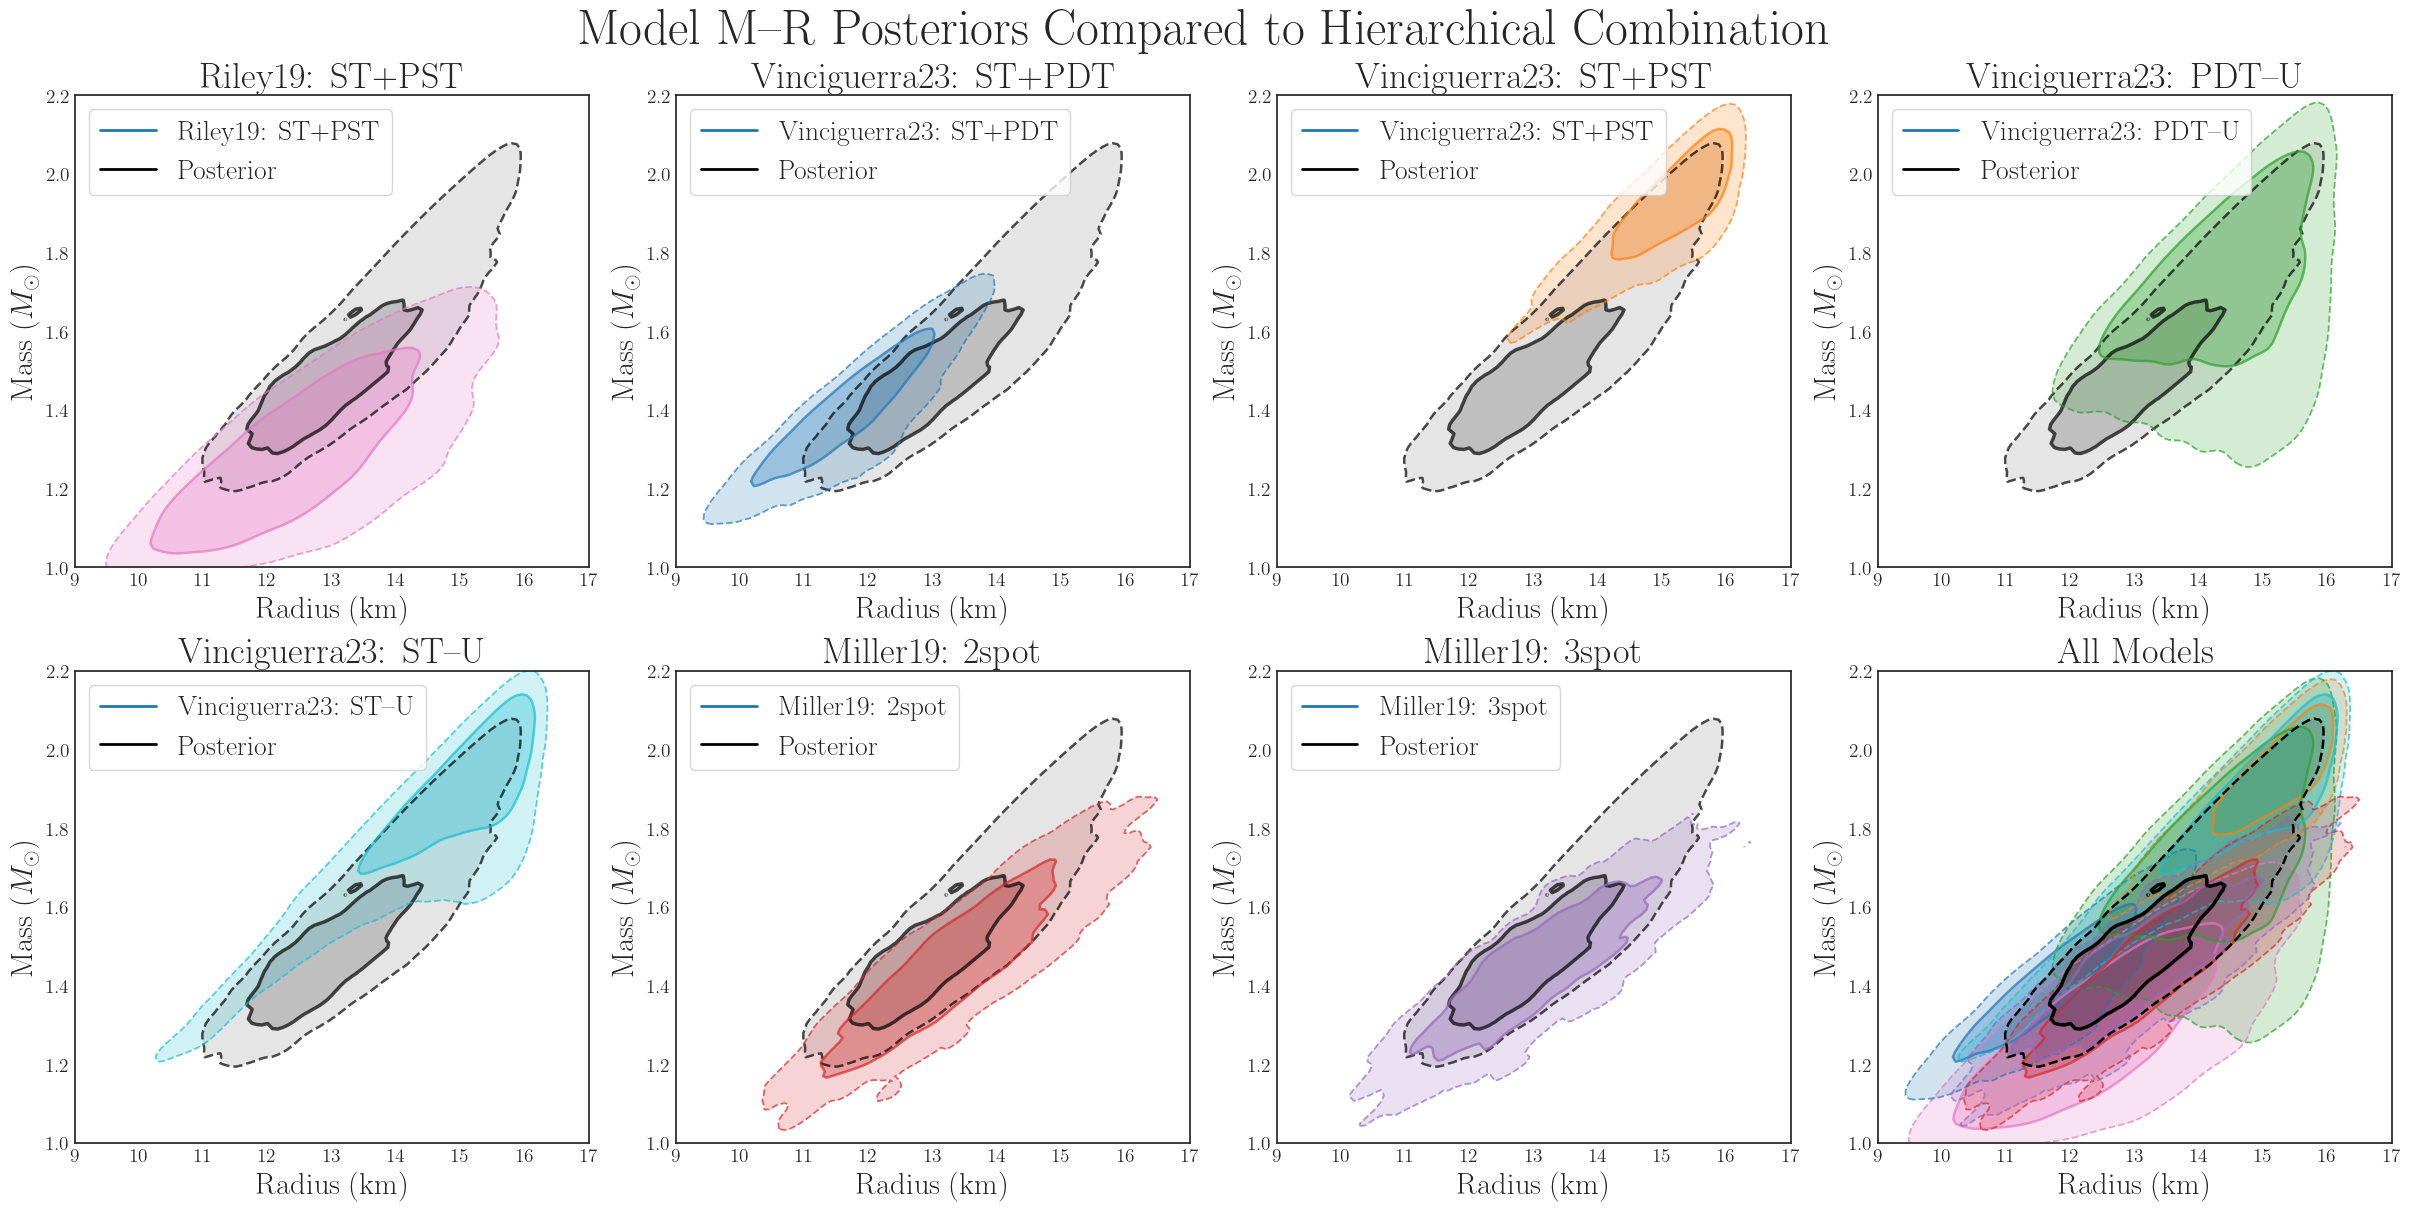

In [ ]:
# ------------------------------------------------------------
# 2D Credible region levels (HPD-style thresholds)
# ------------------------------------------------------------

# Flatten posterior
flat = posterior.ravel()
sorted_idx = np.argsort(flat)[::-1]
sorted_pdf = flat[sorted_idx]

# Cumulative probability
cumulative = np.cumsum(sorted_pdf)
cumulative /= cumulative[-1]

# Find thresholds for 68% and 95%
level_68 = sorted_pdf[np.searchsorted(cumulative, 0.68)]
level_95 = sorted_pdf[np.searchsorted(cumulative, 0.95)]

print("\n2D credible region thresholds:")
print(f"68% contour level: {level_68:.6e}")
print(f"95% contour level: {level_95:.6e}")
plt.style.use('seaborn-v0_8-white')
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

# ------------------------------------------------------------
# HDR level computation
# ------------------------------------------------------------

def compute_hdr_levels(pdf, probs=(0.68, 0.95)):

    flat = pdf.ravel()
    idx = np.argsort(flat)[::-1]
    sorted_pdf = flat[idx]

    cumsum = np.cumsum(sorted_pdf)
    cumsum /= cumsum[-1]

    levels = []
    for p in probs:
        levels.append(sorted_pdf[np.searchsorted(cumsum, p)])

    return levels


# Posterior levels
posterior_lvl68, posterior_lvl95 = compute_hdr_levels(posterior, (0.68, 0.95))

# Models to compare
compare_series = [
    (key, MODELS[key]["label"])
    for key in MODELS
]

#3x3
fig, axes = plt.subplots(3, 3, figsize=(24, 18), constrained_layout=True)
axes = axes.flatten()

def rgba(color, alpha):
    return mpl.colors.to_rgba(color, alpha)

# ------------------------------------------------------------
# Panels 1–7: individual vs posterior
# ------------------------------------------------------------

for ax, (key, label) in zip(axes[:len(compare_series)], compare_series):

    density = g_dict[key]
    lvl68, lvl95 = compute_hdr_levels(density, (0.68, 0.95))

    # Posterior fill
    ax.contourf(
        R_grid, M_grid, posterior,
        levels=[posterior_lvl95, posterior_lvl68, posterior.max()],
        colors=[rgba("black", 0.10), rgba("black", 0.25)],
        antialiased=True
    )

    # Individual fill
    ax.contourf(
        R_grid, M_grid, density,
        levels=[lvl95, lvl68, density.max()],
        colors=[rgba(MODELS[key]["color"], 0.20), rgba(MODELS[key]["color"], 0.45)],
        antialiased=True
    )

    # Posterior outline
    ax.contour(
        R_grid, M_grid, posterior,
        levels=[posterior_lvl95, posterior_lvl68],
        colors=rgba("black", 0.7),
        linewidths=[1.8, 2.5],
        linestyles=['--', '-']
    )

    # Individual outline
    ax.contour(
        R_grid, M_grid, density,
        levels=[lvl95, lvl68],
        colors=rgba(MODELS[key]["color"], 0.7),
        linewidths=[1.3, 1.8],
        linestyles=['--', '-'],
    )

    ax.set_title(label, fontsize=26)
    ax.set_xlabel("Radius (km)", fontsize=22)
    ax.set_ylabel("Mass ($M_\\odot$)", fontsize=22)
    ax.minorticks_on()
    ax.tick_params(labelsize=14)

    ax.legend(
        handles=[
            mpl.lines.Line2D([], [], color='tab:blue', linewidth=2, label=label),
            mpl.lines.Line2D([], [], color='black', linewidth=2, label='Posterior')
        ],
        fontsize=22,
        loc='upper left',
        frameon=True,
        fancybox=True,
        framealpha=0.8
    )

# ------------------------------------------------------------
# Panel 8: all models + posterior
# ------------------------------------------------------------

ax_all = axes[-1]

for key, label in compare_series:

    density = g_dict[key]
    lvl68, lvl95 = compute_hdr_levels(density, (0.68, 0.95))

    # Individual fill
    ax_all.contourf(
        R_grid, M_grid, density,
        levels=[lvl95, lvl68, density.max()],
        colors=[rgba(MODELS[key]["color"], 0.10), rgba(MODELS[key]["color"], 0.2)],
        antialiased=True
    )
    
    # Individual outline
    ax_all.contour(
        R_grid, M_grid, density,
        levels=[lvl95, lvl68],
        colors=rgba(MODELS[key]["color"], 0.7),
        linewidths=[1.3, 1.8],
        linestyles=['--', '-'],
    )

# Posterior fill
ax_all.contourf(
    R_grid, M_grid, posterior,
    levels=[posterior_lvl95, posterior_lvl68, posterior.max()],
    colors=[rgba("black", 0.10), rgba("black", 0.25)],
    antialiased=True
)

# Posterior outline
ax_all.contour(
    R_grid, M_grid, posterior,
    levels=[posterior_lvl95, posterior_lvl68],
    colors='black',
    linewidths=[1.8, 2.5],
    linestyles=['--', '-']
)

ax_all.set_title("All Models", fontsize=26)
ax_all.set_xlabel("Radius (km)", fontsize=22)
ax_all.set_ylabel("Mass ($M_\\odot$)", fontsize=22)
ax_all.minorticks_on()
ax_all.tick_params(labelsize=14)

fig.suptitle(
    "Model M--R Posteriors Compared to Hierarchical Combination",
    fontsize=36
)

plt.show()
posterior_2d = posterior  # for naming consistency

# ------------------------------------------------------------
# Marginal distributions
# ------------------------------------------------------------

# P(R) = ∫ P(M,R) dM
P_R = np.trapz(posterior_2d, M_grid, axis=0)
P_R /= np.trapz(P_R, R_grid)

# P(M) = ∫ P(M,R) dR
P_M = np.trapz(posterior_2d, R_grid, axis=1)
P_M /= np.trapz(P_M, M_grid)

# ------------------------------------------------------------
# Quantiles (16%, 50%, 84%) — properly normalized
# ------------------------------------------------------------

def compute_quantiles(grid, pdf):
    cdf = np.cumsum(pdf) * (grid[1] - grid[0])
    cdf /= cdf[-1]
    return np.interp([0.16, 0.5, 0.84], cdf, grid)

R_q16, R_q50, R_q84 = compute_quantiles(R_grid, P_R)
M_q16, M_q50, M_q84 = compute_quantiles(M_grid, P_M)

In [56]:
P_vi = {key: 0.0 for key in MODELS}
epsilon = 1e-300

for iM, sigma_M in enumerate(sigma_M_grid):
    for iR, sigma_R in enumerate(sigma_R_grid):

        d_sigma_M = sigma_M_grid[1] - sigma_M_grid[0]
        d_sigma_R = sigma_R_grid[1] - sigma_R_grid[0]

        weight_sigma = (
            posterior_sigma_MR[iM, iR]
            * d_sigma_M
            * d_sigma_R
        )

        for alpha in alpha_grid:
            for dM in delta_M_grid:
                for dR in delta_R_grid:

                    # build bad stack
                    b_stack = []

                    for key in MODELS:
                        mu_M = M_med[key] + dM
                        mu_R = R_med[key] + dR

                        var_M = (alpha * S_Mi[key])**2 + sigma_M**2
                        var_R = (alpha * S_Ri[key])**2 + sigma_R**2

                        b = (
                            norm.pdf(MM, loc=mu_M, scale=np.sqrt(var_M)) *
                            norm.pdf(RR, loc=mu_R, scale=np.sqrt(var_R))
                        )

                        b /= np.trapz(
                                np.trapz(b, R_grid, axis=1),
                                M_grid
                            )

                        b_stack.append(b)

                    b_stack = np.array(b_stack)

                    g_exp = g_stack[:, None, :, :]
                    b_exp = b_stack[:, None, :, :]
                    p_exp = p_grid[None, :, None, None]

                    mixture = p_exp * g_exp + (1 - p_exp) * b_exp
                    L_p = np.prod(mixture, axis=0)

                    for idx, key_i in enumerate(MODELS):

                        g_i = g_stack[idx]
                        b_i = b_stack[idx]

                        p_vals = p_grid[:, None, None]

                        numerator_i = p_vals * g_i
                        denominator_i = (
                            p_vals * g_i +
                            (1 - p_vals) * b_i + epsilon
                        )

                        frac = numerator_i / denominator_i
                        weighted = frac * L_p

                        num = np.trapz(weighted, p_grid, axis=0)
                        den = np.trapz(L_p, p_grid, axis=0)

                        P_vi_given_hyper = num / (den + epsilon)

                        contribution = np.trapz(
                            np.trapz(
                                P_vi_given_hyper *
                                P_MR_given_sigma[iM, iR],
                                R_grid,
                                axis=1
                            ),
                            M_grid
                        )

                        P_vi[key_i] += (
                            weight_sigma *
                            contribution
                            / (
                                len(alpha_grid)
                                * len(delta_M_grid)
                                * len(delta_R_grid)
                            )
                        )

for key in MODELS:
    print(f"Posterior probability {key} is good: {P_vi[key]:.4f}")

Posterior probability ST_PST19 is good: 0.0603
Posterior probability ST_PDT is good: 0.0532
Posterior probability ST_PST is good: 0.0252
Posterior probability PDT_U is good: 0.0603
Posterior probability ST_U is good: 0.0479
Posterior probability 2spot is good: 0.0666
Posterior probability 3spot is good: 0.0700
